In [1]:
%load_ext autoreload
%autoreload 2

import os

os.chdir("../../")

### Load Datasets

In [ ]:
import pandas as pd
from src.evals.transcript import get_clean_transcript
df_aa = pd.read_excel("consolidated_results/ai-director-ai-matcher.xlsx")
df_hh = pd.read_csv("consolidated_results/human-director-human-matcher.csv")
df_ah = pd.read_excel("consolidated_results/ai-director-human-matcher.xlsx")
df_ha = pd.read_excel("consolidated_results/human-director-ai-matcher.xlsx")

transcripts_hh = get_clean_transcript(df_hh, condition="Human-Human", drop_incomplete_rounds=True, add_duration_columns=False)
transcripts_aa = get_clean_transcript(df_aa, condition="AI-AI", drop_incomplete_rounds=True, add_duration_columns=False)
transcripts_ah = get_clean_transcript(df_ah, condition="AI-Human", drop_incomplete_rounds=True, add_duration_columns=False)
transcripts_ha = get_clean_transcript(df_ha, condition="Human-AI", drop_incomplete_rounds=True, add_duration_columns=False)
all_transcripts = pd.concat([transcripts_hh, transcripts_aa, transcripts_ah, transcripts_ha], axis=0).reset_index(drop=True)

all_transcripts.shape, all_transcripts.columns

((36, 5),
 Index(['pair_id', 'condition', 'round_ix', 'accuracy', 'transcript'], dtype='object'))

In [84]:
df_aa["session_config_name"].value_counts()

session_config_name
ai_vs_ai_gemini_pro_vs_gpt    2
ai_vs_ai_gpt_vs_gemini_pro    2
ai_vs_ai_gpt_vs_claude        2
ai_vs_ai_claude_vs_gpt        2
ai_vs_ai_gpt_vs_gemini        1
Name: count, dtype: int64

### Accuracy

In [9]:
all_transcripts["condition"].value_counts()

condition
Human-Human    128
Human-AI        88
AI-AI           64
AI-Human        64
Name: count, dtype: int64

In [10]:
from src.evals.accuracy import get_accuracy_from_transcript_df

accuracy_df = get_accuracy_from_transcript_df(all_transcripts)
accuracy_df.sample(5)

,condition,pair_id,R1,R2,R3,R4
3,Human-Human,3kk7u0fy_ddls1zzn_ldgryt73,91.7,83.3,100.0,100.0
0,Human-Human,3kk7u0fy_08dnx2dx_ljtwijvs,83.3,91.7,91.7,83.3
66,Human-AI,63d3ccaecce99faa457fb049,58.3,50.0,58.3,66.7
74,Human-AI,5d0eb8f40c09d600174dca28,50.0,58.3,50.0,66.7
59,AI-Human,610a151c96de07b15f28c8cb,91.7,16.7,25.0,91.7


In [11]:
### The following code does not filter out the incomplete rounds, so it is deprecated. ###
# from src.evals.accuracy import get_accuracy

# accu_hh = get_accuracy(df_hh, num_of_rounds=4, precision=1, include_cols=["pair_id"])
# accu_aa = get_accuracy(df_aa, num_of_rounds=4, precision=1, include_cols=["pair_id"])
# accu_ah = get_accuracy(df_ah, num_of_rounds=4, precision=1, include_cols=["pair_id"])
# accu_ha = get_accuracy(df_ha, num_of_rounds=4, precision=1, include_cols=["pair_id"])
# accu_hh.insert(0, "condition", "Human-Human")
# accu_aa.insert(0, "condition", "AI-AI")
# accu_ah.insert(0, "condition", "AI-Human")
# accu_ha.insert(0, "condition", "Human-AI")
# accuracy_df = pd.concat([accu_hh, accu_aa, accu_ah, accu_ha], axis=0).reset_index(drop=True)
# accuracy_df.head()

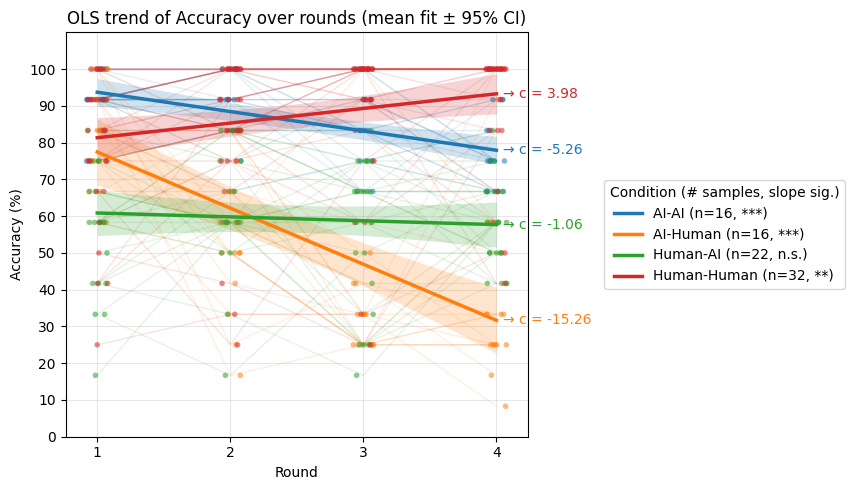

In [33]:
from src.evals.accuracy import plot_ols_trend

fig, ax = plot_ols_trend(accuracy_df, show_points=True, 
                         show_trajectories=True, annotate_slope=True,
                         save_fp="figures/accuracy_ols_trend_detailed.png")
fig.show()

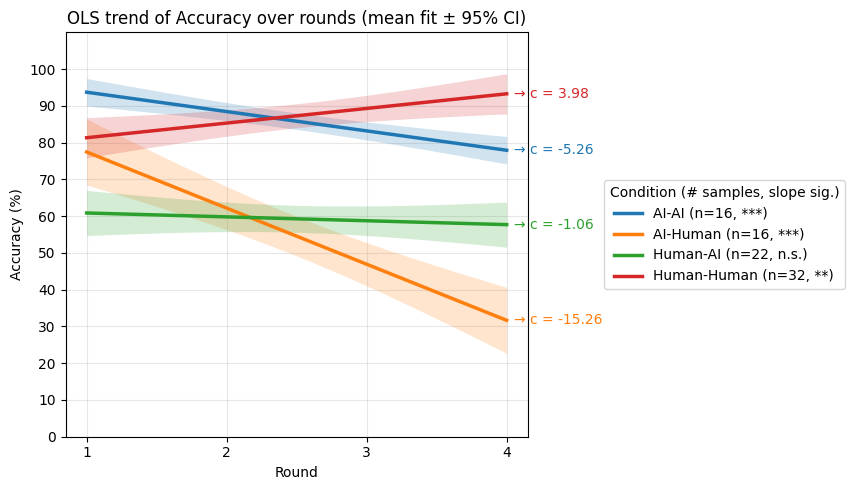

In [35]:
fig, ax = plot_ols_trend(accuracy_df, show_points=False, 
                         show_trajectories=False, annotate_slope=True,
                         save_fp="figures/accuracy_ols_trend.png")
fig.show()

### Efficiency

In [12]:
from src.evals.efficiency import calculate_efficiency_metrics_for_round


efficiency_results = []

for _, row in all_transcripts.iterrows():
    metrics = calculate_efficiency_metrics_for_round(row["transcript"])
    efficiency_results.append(
        {
            **row.to_dict(),
            **metrics
        }
    )

efficiency_df = pd.DataFrame(efficiency_results)
efficiency_df.head()

,pair_id,condition,round_ix,accuracy,transcript,# words,# turns,# utterances,words_per_turn,words_per_utterance,utterances_per_turn,round_duration_seconds,avg_turn_duration_seconds,avg_utterance_duration_seconds,round_duration,avg_turn_duration,avg_utterance_duration
0,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,1,83.333333,[18:27:25] director: Hi there. The first baske...,374,32,33,11.687500,11.333333,1.031250,1123.0,0.562500,35.093750,00:18:43,00:00:00,00:00:35
1,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,2,91.666667,[18:47:04] director: hi there \n\n[18:47:11] m...,352,31,34,11.354839,10.352941,1.096774,1067.0,4.258065,32.333333,00:17:47,00:00:04,00:00:32
2,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,3,91.666667,[19:05:34] director: hi there \n\n[19:05:41] m...,268,26,26,10.307692,10.307692,1.000000,633.0,0.000000,25.320000,00:10:33,00:00:00,00:00:25
3,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,4,83.333333,[19:16:36] director: hi there! \n\n[19:16:42] ...,299,27,27,11.074074,11.074074,1.000000,807.0,0.000000,31.038462,00:13:27,00:00:00,00:00:31
4,3kk7u0fy_2ifxj59u_qhyb02an,Human-Human,1,91.666667,[18:16:40] director: 1 the rabbit facing your ...,299,19,38,15.736842,7.868421,2.000000,930.0,23.789474,25.135135,00:15:30,00:00:23,00:00:25


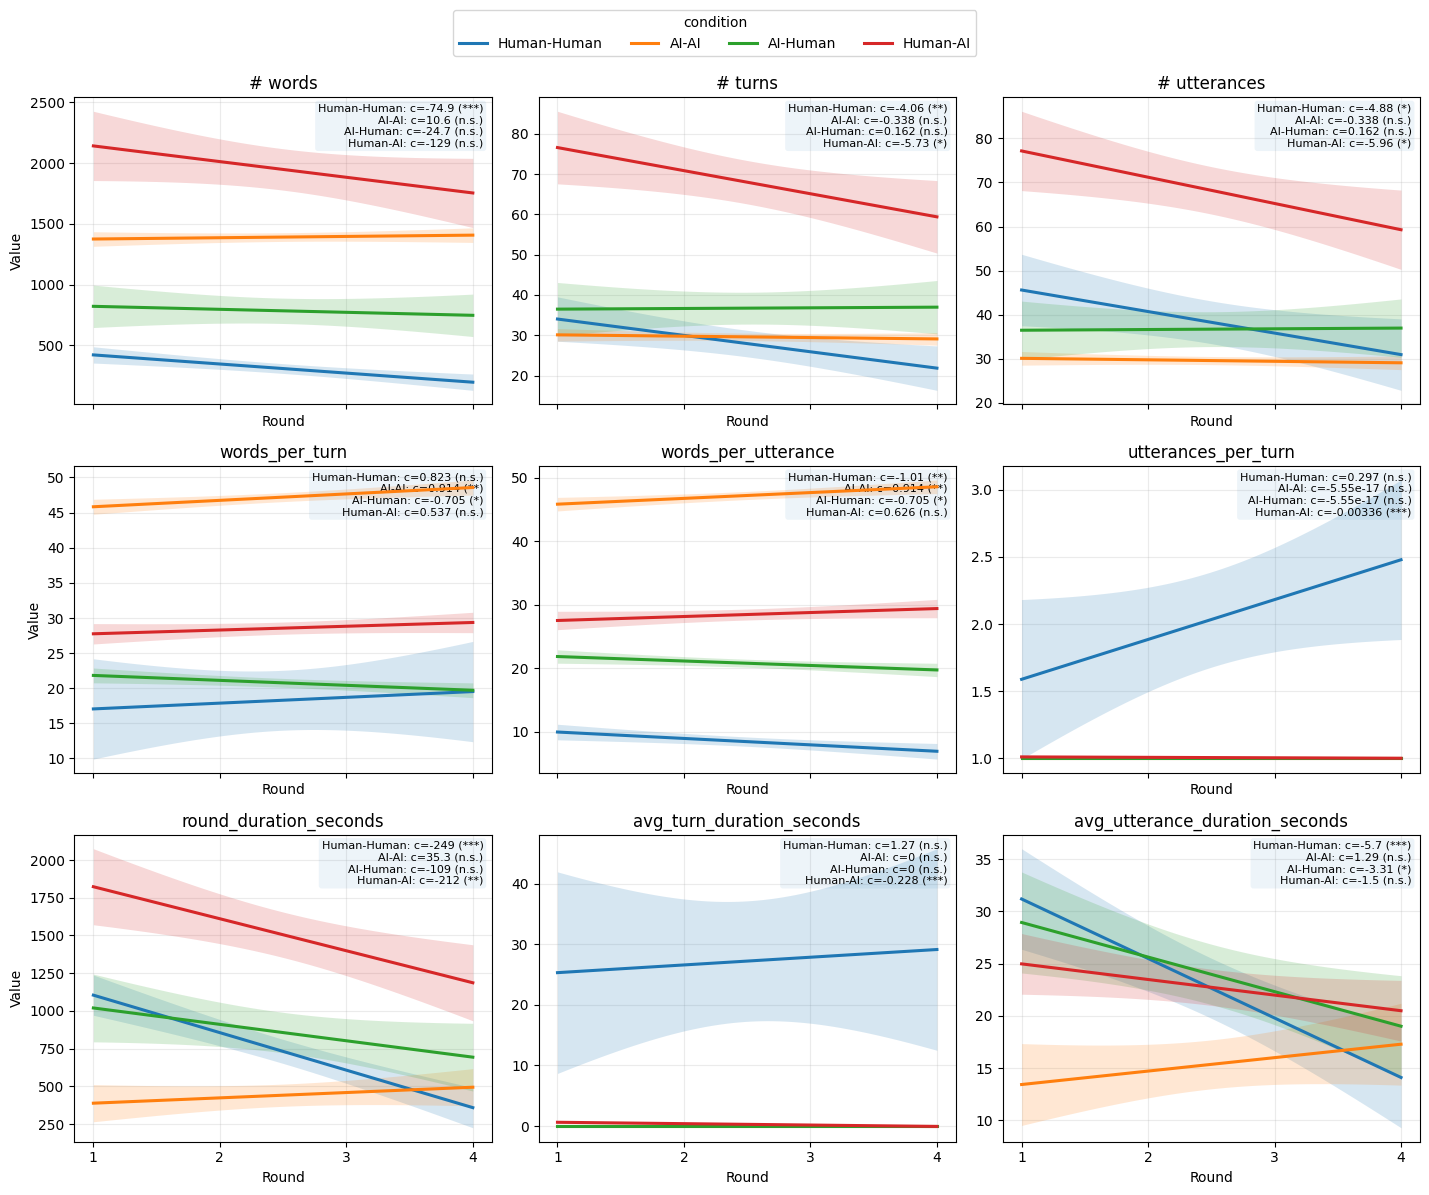

In [136]:
from src.evals.visualizers import plot_ols_metrics_grid

metrics_cols = list(metrics.keys())[:-3]
fig, axes = plot_ols_metrics_grid(efficiency_df, metrics_cols, nrows=3, show_points=False,
                                              save_fp="figures/ols_efficiency_metrics.png")
fig.show()

### Entrainment

In [3]:
import pandas as pd

all_and_full_annotated_results_fp = "consolidated_results/all_and_full_annotated_results.csv"

if os.path.exists(all_and_full_annotated_results_fp):
    all_and_full_annotated_results_df = pd.read_csv(all_and_full_annotated_results_fp)
    print("Loaded existing results from:", all_and_full_annotated_results_fp)
else:
    all_and_full_annotated_results_df = efficiency_df.copy()

efficiency_df.columns

Loaded existing results from: consolidated_results/all_and_full_annotated_results.csv


NameError: name 'efficiency_df' is not defined

In [74]:
efficiency_df.shape, efficiency_df.columns

((344, 18),
 Index(['pair_id', 'condition', 'round_ix', 'accuracy', 'transcript', '# words',
        '# turns', '# utterances', 'words_per_turn', 'words_per_utterance',
        'utterances_per_turn', 'round_duration_seconds',
        'avg_turn_duration_seconds', 'avg_utterance_duration_seconds',
        'round_duration', 'avg_turn_duration', 'avg_utterance_duration',
        'llm_extracted_object_descriptions_GPT_5'],
       dtype='object'))

In [75]:
from src.evals.red import whitespace_tokens


extraction_col = "llm_extracted_object_descriptions_GPT_5"

for ix, row in efficiency_df.iterrows():
    if extraction_col not in row or pd.isna(row[extraction_col]):
        match = all_and_full_annotated_results_df[
            (all_and_full_annotated_results_df["pair_id"] == row["pair_id"]) & 
            (all_and_full_annotated_results_df["round_ix"] == row["round_ix"]) &
            (all_and_full_annotated_results_df["condition"] == row["condition"])
        ]
        if not match.empty and not pd.isna(match[extraction_col].values[0]):
            efficiency_df.at[ix, extraction_col] = match[extraction_col].values[0]
        else:
            print(f"No matching annotated data found for Row {ix}.")
    else:
        print(f"Row {ix} already has LLM extracted descriptions.")

# efficiency_df.to_csv(all_and_full_annotated_results_fp, index=False)

Row 0 already has LLM extracted descriptions.
Row 1 already has LLM extracted descriptions.
Row 2 already has LLM extracted descriptions.
Row 3 already has LLM extracted descriptions.
Row 4 already has LLM extracted descriptions.
Row 5 already has LLM extracted descriptions.
Row 6 already has LLM extracted descriptions.
Row 7 already has LLM extracted descriptions.
Row 8 already has LLM extracted descriptions.
Row 9 already has LLM extracted descriptions.
Row 10 already has LLM extracted descriptions.
Row 11 already has LLM extracted descriptions.
Row 12 already has LLM extracted descriptions.
Row 13 already has LLM extracted descriptions.
Row 14 already has LLM extracted descriptions.
Row 15 already has LLM extracted descriptions.
Row 16 already has LLM extracted descriptions.
Row 17 already has LLM extracted descriptions.
Row 18 already has LLM extracted descriptions.
Row 19 already has LLM extracted descriptions.
Row 20 already has LLM extracted descriptions.
Row 21 already has LLM 

In [76]:
efficiency_df[extraction_col].notna().sum(), efficiency_df[extraction_col].isna().sum()

(np.int64(344), np.int64(0))

In [77]:
efficiency_df.condition.value_counts() / 4

condition
Human-Human    32.0
Human-AI       22.0
AI-AI          16.0
AI-Human       16.0
Name: count, dtype: float64

In [78]:
efficiency_df.head()

,pair_id,condition,round_ix,accuracy,transcript,# words,# turns,# utterances,words_per_turn,words_per_utterance,utterances_per_turn,round_duration_seconds,avg_turn_duration_seconds,avg_utterance_duration_seconds,round_duration,avg_turn_duration,avg_utterance_duration,llm_extracted_object_descriptions_GPT_5
0,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,1,83.333333,[18:27:25] director: Hi there. The first baske...,374,32,33,11.687500,11.333333,1.031250,1123.0,0.562500,35.093750,00:18:43,00:00:00,00:00:35,"{\n ""object_#1"": ""rabbit facing to the righ..."
1,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,2,91.666667,[18:47:04] director: hi there \n\n[18:47:11] m...,352,31,34,11.354839,10.352941,1.096774,1067.0,4.258065,32.333333,00:17:47,00:00:04,00:00:32,"{\n ""object_#1"": ""a rectangle basket, the r..."
2,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,3,91.666667,[19:05:34] director: hi there \n\n[19:05:41] m...,268,26,26,10.307692,10.307692,1.000000,633.0,0.000000,25.320000,00:10:33,00:00:00,00:00:25,"{\n ""object_#1"": ""2 tone basket, dark brown..."
3,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,4,83.333333,[19:16:36] director: hi there! \n\n[19:16:42] ...,299,27,27,11.074074,11.074074,1.000000,807.0,0.000000,31.038462,00:13:27,00:00:00,00:00:31,"{\n ""object_#1"": ""shallow light colored bas..."
4,3kk7u0fy_2ifxj59u_qhyb02an,Human-Human,1,91.666667,[18:16:40] director: 1 the rabbit facing your ...,299,19,38,15.736842,7.868421,2.000000,930.0,23.789474,25.135135,00:15:30,00:00:23,00:00:25,"{\n ""object_#1"": ""the rabbit facing your ri..."


In [80]:
from src.evals.entrainment import parse_llm_response

efficiency_df["extracted_descriptions"] = efficiency_df[extraction_col].apply(parse_llm_response)
efficiency_df["extracted_descriptions"].head()

0    {'object_#1': 'rabbit facing to the right', 'o...
1    {'object_#1': 'a rectangle basket, the right s...
2    {'object_#1': '2 tone basket, dark brown body ...
3    {'object_#1': 'shallow light colored basket wi...
4    {'object_#1': 'the rabbit facing your right', ...
Name: extracted_descriptions, dtype: object

#### RED token count

In [81]:
from src.evals.red import whitespace_tokens

for ix, row in efficiency_df.iterrows():
    if len(row["extracted_descriptions"]) == 0:
        continue
    
    descriptions = " ".join(row["extracted_descriptions"].values())
    efficiency_df.at[ix, "red_tokens"] = len(whitespace_tokens(descriptions))

In [82]:
efficiency_df_annotated = efficiency_df.copy()[efficiency_df["red_tokens"].notna()]
efficiency_df_annotated["red_tokens"].describe()

count    344.000000
mean     280.813953
std      154.509306
min       29.000000
25%      138.750000
50%      281.500000
75%      401.500000
max      732.000000
Name: red_tokens, dtype: float64

In [85]:
efficiency_df_annotated.to_json("consolidated_results/efficiency_results_with_red_annotations.json", 
                                orient="records", indent=4)

In [86]:
efficiency_df_annotated.columns

Index(['pair_id', 'condition', 'round_ix', 'accuracy', 'transcript', '# words',
       '# turns', '# utterances', 'words_per_turn', 'words_per_utterance',
       'utterances_per_turn', 'round_duration_seconds',
       'avg_turn_duration_seconds', 'avg_utterance_duration_seconds',
       'round_duration', 'avg_turn_duration', 'avg_utterance_duration',
       'llm_extracted_object_descriptions_GPT_5', 'extracted_descriptions',
       'red_tokens'],
      dtype='object')

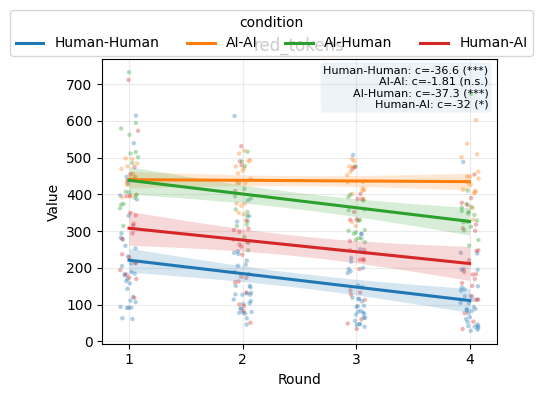

In [83]:
fig, axes = plot_ols_metrics_grid(efficiency_df_annotated, ["red_tokens"],
                                  show_significance=True,
                                  nrows=1,
                                  save_fp="figures/ols_red_tokens.png")
fig.show()

#### RED Metrics

In [4]:
import pandas as pd

efficiency_df = pd.read_json("consolidated_results/efficiency_results_with_red_annotations.json")

In [5]:
object_filename_map = {
  "rounds": [
    {
      "round": 1,
      "baskets": [
        "076.png", "001.png", "015.png", "009.png", "022.png", "033.png",
        "012.png", "040.png", "037.png", "019.png", "065.png", "017.png"
      ]
    },
    {
      "round": 2,
      "baskets": [
        "015.png", "037.png", "001.png", "022.png", "040.png", "076.png",
        "033.png", "019.png", "012.png", "065.png", "017.png", "009.png"
      ]
    },
    {
      "round": 3,
      "baskets": [
        "012.png", "009.png", "033.png", "076.png", "017.png", "037.png",
        "001.png", "040.png", "022.png", "019.png", "065.png", "015.png"
      ]
    },
    {
      "round": 4,
      "baskets": [
        "019.png", "022.png", "076.png", "012.png", "065.png", "001.png",
        "037.png", "015.png", "033.png", "009.png", "017.png", "040.png"
      ]
    },
    {
      "fullList": [
        "076.png", "001.png", "015.png", "009.png", "022.png", "033.png",
        "012.png", "040.png", "037.png", "019.png", "065.png", "017.png",
        "005.png", "039.png", "057.png", "081.png", "077.png", "078.png"
      ]
    }
  ]
}
object_filename_map = object_filename_map["rounds"]


In [6]:
from tqdm import tqdm

extracted_descriptions = []

for _, row in tqdm(efficiency_df.iterrows(), total=len(efficiency_df)):
    pair_id = row["pair_id"]
    round_ix = row["round_ix"]
    condition = row["condition"]
    transcript = row["transcript"]
    description_dict = row["extracted_descriptions"]
    for i, key in enumerate(description_dict):
        object_ix = i+1
        
        if f"object_#{object_ix}" != key:
            print(
                f"Warning: Expected object_#{object_ix} but got {key} in pair {pair_id}, round {round_ix}"
            )
            continue
        
        filename = object_filename_map[round_ix - 1]["baskets"][i]
        object_description = description_dict.get(key, None)
        extracted_descriptions.append(
            {
                "pair_id": pair_id,
                "condition": condition,
                "round_ix": round_ix,
                "transcript": transcript,
                "object_ix": object_ix,
                "filename": filename,
                "object_description": object_description,
            }
        )

extracted_descriptions_df = pd.DataFrame(extracted_descriptions)
extracted_descriptions_df.shape, extracted_descriptions_df.columns

  0%|          | 0/344 [00:00<?, ?it/s]

100%|██████████| 344/344 [00:00<00:00, 14058.25it/s]


((4128, 7),
 Index(['pair_id', 'condition', 'round_ix', 'transcript', 'object_ix',
        'filename', 'object_description'],
       dtype='object'))

In [ ]:
# extracted_descriptions_df.to_csv("consolidated_results/aligned_extracted_object_descriptions.csv", index=False)

In [7]:
import pandas as pd

extracted_descriptions_df = pd.read_csv("consolidated_results/aligned_extracted_object_descriptions.csv")
extracted_descriptions_df

,pair_id,condition,round_ix,transcript,object_ix,filename,object_description,clip_score,contrastive_clip_score
0,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,1,[18:27:25] director: Hi there. The first baske...,1,076.png,rabbit facing to the right,23.387989,-0.898606
1,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,1,[18:27:25] director: Hi there. The first baske...,2,001.png,"basic round basket, round, has a handle, unifo...",25.962502,1.909953
2,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,1,[18:27:25] director: Hi there. The first baske...,3,015.png,"rectangle, right side of the lid is propped op...",14.502266,-10.592122
3,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,1,[18:27:25] director: Hi there. The first baske...,4,009.png,"2 tone white and light brown, the handle comes...",25.246346,1.128692
4,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,1,[18:27:25] director: Hi there. The first baske...,5,022.png,"fairly basic, uniform brown color, a braided h...",27.671200,3.773988
...,...,...,...,...,...,...,...,...,...
4123,63614ad9841a7d16ad04512a,Human-AI,4,[22:15:34] director: Number 1 is coiled round ...,8,015.png,"the one with an open lide on one side, closed ...",26.699718,5.751288
4124,63614ad9841a7d16ad04512a,Human-AI,4,[22:15:34] director: Number 1 is coiled round ...,9,033.png,"an animal, with both eyes visible, tiny feet, ...",18.627974,-3.054252
4125,63614ad9841a7d16ad04512a,Human-AI,4,[22:15:34] director: Number 1 is coiled round ...,10,009.png,"the one with the white pattern in the middle, ...",19.910971,-1.654619
4126,63614ad9841a7d16ad04512a,Human-AI,4,[22:15:34] director: Number 1 is coiled round ...,11,017.png,"looks like a deep purse, that's mostly one color",17.102358,-4.718560


In [8]:
extracted_descriptions_piv = extracted_descriptions_df.pivot(
    index=["pair_id", "condition", "filename",],
    columns="round_ix",
    values="object_description"
)
extracted_descriptions_piv

round_ix                                                                     1  \
pair_id  condition filename                                                      
12mwnjm1 AI-AI     001.png   a deep, rounded bucket-style wicker basket, a ...   
                   009.png   an oval, boat-shaped basket in pale/whitewashe...   
                   012.png   a rectangular tote basket with a single arched...   
                   015.png   a rectangular, boxy picnic basket, a tall vert...   
                   017.png   a compact handbag-style tan basket with ONE ar...   
...                                                                        ...   
y5q3cuyo AI-AI     033.png   the round, lidded wicker basket that looks lik...   
                   037.png   a tall, cylindrical brown wicker basket (like ...   
                   040.png   a squat oval basket with a dark gray-brown bod...   
                   065.png   a wide, deep round tub basket, TWO thick side ...   
                   076.png   the light tan wicker basket shaped like a duck...   

round_ix                                                                     2  \
pair_id  condition filename                                                      
12mwnjm1 AI-AI     001.png   deep rounded bucket-shaped wicker basket, VERY...   
                   009.png   compact tan handbag/purse-shaped basket, ONE a...   
                   012.png   rectangular tote/handbag basket, ONE arched ha...   
                   015.png   rectangular, boxy wicker picnic basket, tall u...   
                   017.png   open round tub/bucket basket, NO big arched ha...   
...                                                                        ...   
y5q3cuyo AI-AI     033.png   round, lidded wicker basket, animal/cat face o...   
                   037.png   tall, straight-sided cylindrical wicker basket...   
                   040.png   squat oval basket that’s two-tone, dark gray/b...   
                   065.png   wide, deep ROUND tub basket, TWO thick side ha...   
                   076.png   lidded wicker basket shaped like a duck, oval ...   

round_ix                                                                     3  \
pair_id  condition filename                                                      
12mwnjm1 AI-AI     001.png   deep rounded bucket-style wicker basket, SINGL...   
                   009.png   very pale/whitewashed oval “boat-shaped” baske...   
                   012.png   a rectangular tote basket, one arched handle, ...   
                   015.png   low squat rectangular brown basket, ONE super-...   
                   017.png   plain medium-brown wicker “handbag” basket, sq...   
...                                                                        ...   
y5q3cuyo AI-AI     033.png   round lidded wicker basket, animal/cat face on...   
                   037.png   tall, straight-sided cylindrical wicker basket...   
                   040.png   squat oval basket that’s two-tone, dark gray/b...   
                   065.png   very shallow ROUND tray-basket, single light t...   
                   076.png   lidded basket shaped like a duck in profile, o...   

round_ix                                                                     4  
pair_id  condition filename                                                     
12mwnjm1 AI-AI     001.png   a deep rounded bucket-style wicker basket, a S...  
                   009.png   the very pale/whitewashed oval “boat-shaped” b...  
                   012.png   a rectangular tote basket, ONE arched handle, ...  
                   015.png   the rectangular, boxy picnic basket, a tall up...  
                   017.png   a compact tan handbag/purse-shaped basket, ONE...  
...                                                                        ...  
y5q3cuyo AI-AI     033.png   the round, lidded wicker basket, an animal/cat...  
                   037.png   a tall, straight-sided cylindrical wicker

In [9]:
extracted_descriptions_df.condition.value_counts()

condition
Human-Human    1536
Human-AI       1056
AI-AI           768
AI-Human        768
Name: count, dtype: int64

In [10]:
round_cols = [1, 2, 3, 4]


extracted_descriptions_piv_agg = (
    extracted_descriptions_piv
    .groupby(['pair_id', 'condition'])[round_cols]
    .agg(lambda x: ' '.join(x.dropna().astype(str)))
    .reset_index()
)

extracted_descriptions_piv_agg

round_ix,pair_id,condition,1,2,3,4
0,12mwnjm1,AI-AI,"a deep, rounded bucket-style wicker basket, a ...","deep rounded bucket-shaped wicker basket, VERY...","deep rounded bucket-style wicker basket, SINGL...","a deep rounded bucket-style wicker basket, a S..."
1,1hs8hysu,AI-AI,"a plain, deep rounded bucket basket, with a si...","a deep, round bucket-shaped basket (almost hal...","very deep, rounded bucket/half-sphere basket, ...",a deep rounded bucket/half-sphere basket with ...
2,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,"basic round basket, round, has a handle, unifo...","a very standard round basket, uniform brown co...","uniform brown basket, slightly taller round bo...","a uniform brown basket, very nicely arched han..."
3,3kk7u0fy_2ifxj59u_qhyb02an,Human-Human,"the very smooth brown one, has the smoothest b...",is the shiniest in all brown the handle has br...,the all brown shiny one the handle and body ha...,"the shiniest of them all, has one handle has b..."
4,3kk7u0fy_2ivt4mpj_g7urxzlh,Human-Human,"oval shaped basked with a handle, oblong baske...","oval shaped, doesn't look like wicker, its a m...","round and doesn't look like wicker, one handle...","the one that doesn't appear to be wicker, roun..."
...,...,...,...,...,...,...
81,rxaitysx,AI-AI,"deep, very rounded bucket-shaped wicker basket...","deep, very round bowl/bucket-shaped wicker bas...","a very deep, round bucket-shaped basket, ONE t...","a very deep, round bucket-shaped basket (almos..."
82,to92yphx,AI-AI,"a round, bucket-shaped brown wicker basket, a ...","a deep, round brown bucket basket, a thick arc...","a deep, round brown bucket basket, ONE thick a...","a deep, round brown bucket basket, ONE thick a..."
83,ufdasj38,AI-AI,"deep, bucket-shaped brown wicker basket, thick...","a deep, rounded pot/bucket-shaped wicker baske...","deep, rounded pot/bucket-shaped wicker basket,...","deep, rounded pot/bucket-shaped wicker basket,..."
84,xiie2q84,AI-AI,"deep, rounded bucket-shaped wicker basket, ver...","very deep, round bucket/bowl-shaped wicker bas...","a very deep, super-round bucket/bowl-shaped wi...","a very deep, super-round bucket/bowl wicker ba..."


In [16]:
# for ix, row in efficiency_df.iterrows():
#     pair_id = row['pair_id']
#     round_ix = row['round_ix']
#     sub = extracted_descriptions_df[
#         (extracted_descriptions_df['pair_id'] == pair_id) &
#         (extracted_descriptions_df['round_ix'] == round_ix)
#     ]
#     avg_clip_score = sub['clip_score'].mean()
#     avg_contrastive_clip_score = sub['contrastive_clip_score'].mean()
#     efficiency_df.at[ix, 'avg_clip_score'] = avg_clip_score
#     efficiency_df.at[ix, 'avg_contrastive_clip_score'] = avg_contrastive_clip_score

# efficiency_df.to_json("consolidated_results/efficiency_results_with_red_annotations.json", 
#                       orient="records", indent=4)

### Aggregate

In [58]:
from src.evals.red import compute_red_metrics

df_items_agg, df_summary_agg = compute_red_metrics(extracted_descriptions_piv_agg, 
                                                   group_cols=["condition"], use_spacy=True)
df_summary_agg.round(2)

Loaded spaCy model for tokenization.


,condition,RALR_mean,R2LR_mean,R3LR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean,WNRA_mean,WNR14_mean,RLA_mean,RL14_mean,COSA_mean,COS14_mean,JACCA_mean,JACC14_mean
0,AI-AI,0.01,-0.01,0.04,-0.01,0.52,0.77,0.73,0.56,0.56,0.51,0.51,0.92,0.92,0.69,0.62
1,AI-Human,0.20,0.18,0.24,0.18,0.58,0.76,0.74,0.72,0.63,0.34,0.29,0.90,0.87,0.63,0.53
2,Human-AI,0.19,0.15,0.17,0.26,0.67,0.63,0.60,0.73,0.59,0.30,0.25,0.87,0.82,0.43,0.32
3,Human-Human,0.25,0.14,0.25,0.37,0.72,0.72,0.67,0.49,0.43,0.46,0.31,0.89,0.82,0.51,0.36


In [42]:
# compute_red_metrics(extracted_descriptions_piv_agg, group_cols=["condition"], use_spacy=False)[1].round(2)

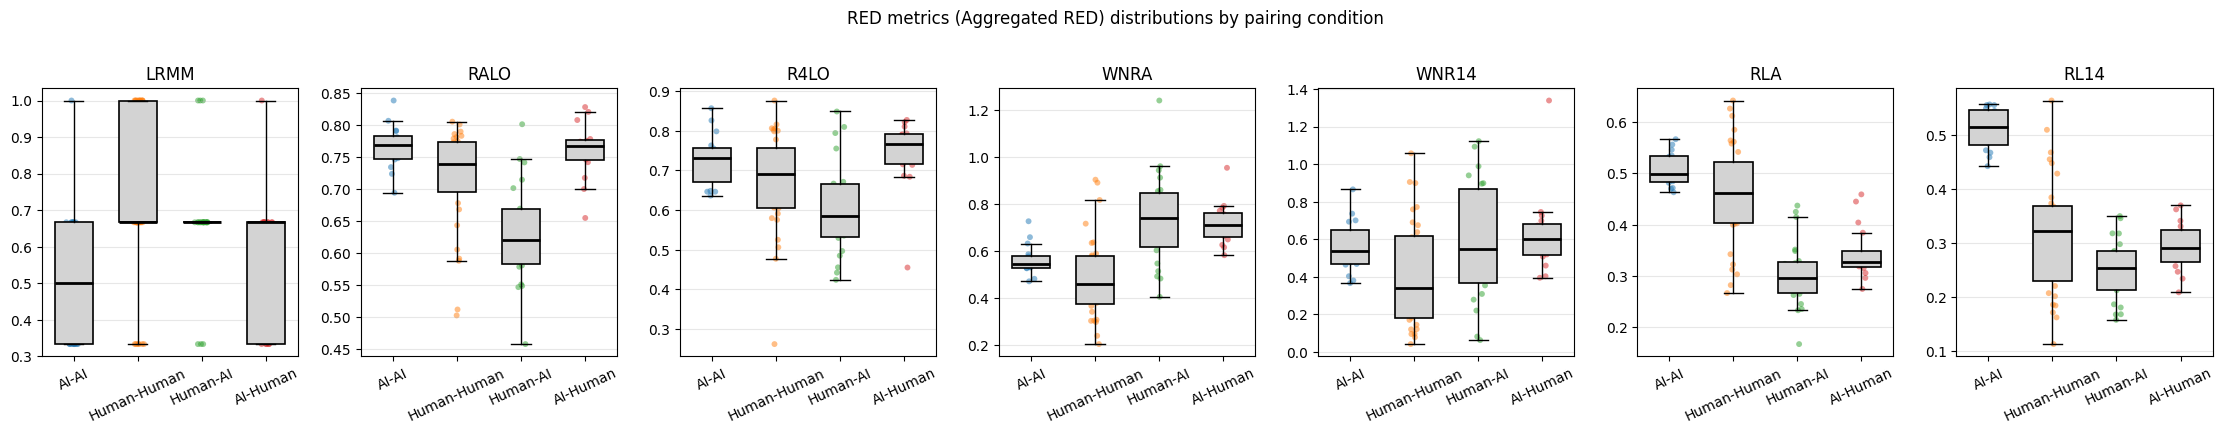

In [27]:
from src.evals.visualizers import plot_boxplots_by_condition


cols = ['LRMM', 'RALO', 'R4LO', 'WNRA', 'WNR14', 'RLA', 'RL14']

fig, axes = plot_boxplots_by_condition(
    df_items_agg.reset_index(),
    cols,
    condition_col="condition",
    title="RED metrics (Aggregated RED) distributions by pairing condition",
    save_fp=None,  # e.g. "boxplots.png"
)
fig.show()

### Average

In [91]:
results = []
use_spacy_sum_df = compute_red_metrics(extracted_descriptions_piv, group_cols=["condition"], use_spacy=True)[1]
use_spacy_sum_df.insert(0, "method", "spacy: content words")
results.append(use_spacy_sum_df)

no_spacy_sum_df = compute_red_metrics(extracted_descriptions_piv, group_cols=["condition"], no_stop_words=False, use_spacy=False)[1]
no_spacy_sum_df.insert(0, "method", "no spacy: all words")
results.append(no_spacy_sum_df)

no_spacy_no_stopwords_sum_df = compute_red_metrics(extracted_descriptions_piv, group_cols=["condition"], no_stop_words=True, use_spacy=False)[1]
no_spacy_no_stopwords_sum_df.insert(0, "method", "no spacy: no stop words")
results.append(no_spacy_no_stopwords_sum_df)

results_df = pd.concat(results, axis=0).reset_index(drop=True)
results_df.round(2)

Loaded spaCy model for tokenization.


,method,condition,RALR_mean,R2LR_mean,R3LR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean,WNRA_mean,WNR14_mean,RLA_mean,RL14_mean,COSA_mean,COS14_mean,JACCA_mean,JACC14_mean
0,spacy: content words,AI-AI,-0.02,-0.03,0.01,-0.04,0.50,0.59,0.63,0.57,0.57,0.51,0.52,0.82,0.87,0.51,0.51
1,spacy: content words,AI-Human,0.09,0.07,0.13,0.06,0.55,0.38,0.36,0.82,0.76,0.29,0.25,0.66,0.65,0.26,0.22
2,spacy: content words,Human-AI,-0.00,-0.06,-0.04,0.09,0.54,0.44,0.43,0.90,0.71,0.31,0.25,0.63,0.62,0.28,0.22
3,spacy: content words,Human-Human,0.10,-0.02,0.10,0.23,0.52,0.62,0.53,0.58,0.51,0.49,0.32,0.74,0.62,0.43,0.27
4,no spacy: all words,AI-AI,-0.01,-0.01,0.02,-0.04,0.48,0.52,0.53,0.64,0.65,0.45,0.44,0.82,0.85,0.39,0.37
5,no spacy: all words,AI-Human,0.11,0.08,0.15,0.09,0.56,0.31,0.30,0.86,0.77,0.24,0.21,0.70,0.68,0.19,0.16
6,no spacy: all words,Human-AI,0.01,-0.06,-0.02,0.12,0.56,0.39,0.38,0.95,0.72,0.28,0.22,0.64,0.62,0.23,0.18
7,no spacy: all words,Human-Human,0.13,-0.00,0.12,0.26,0.55,0.55,0.45,0.63,0.52,0.43,0.27,0.74,0.63,0.36,0.22
8,no spacy: no stop words,AI-AI,-0.02,-0.03,0.00,-0.05,0.47,0.49,0.49,0.65,0.67,0.44,0.42,0.84,0.86,0.37,0.35
9,no spacy: no stop words,AI-Human,0.10,0.09,0.13,0.08,0.54,0.28,0.25,0.85,0.79,0.23,0.18,0.71,0.68,0.17,0.13


In [100]:
cols = ["Human-Human", "AI-AI", "AI-Human", "Human-AI"]
results_df.pivot(index="condition", columns="method", values=["RALO_mean","R4LO_mean","WNRA_mean",
                                                              "WNR14_mean","RLA_mean","RL14_mean"]).T[cols].round(2)

condition                           Human-Human  AI-AI  AI-Human  Human-AI
           method                                                         
RALO_mean  no spacy: all words             0.55   0.52      0.31      0.39
           no spacy: no stop words         0.55   0.49      0.28      0.35
           spacy: content words            0.62   0.59      0.38      0.44
R4LO_mean  no spacy: all words             0.45   0.53      0.30      0.38
           no spacy: no stop words         0.43   0.49      0.25      0.33
           spacy: content words            0.53   0.63      0.36      0.43
WNRA_mean  no spacy: all words             0.63   0.64      0.86      0.95
           no spacy: no stop words         0.60   0.65      0.85      0.94
           spacy: content words            0.58   0.57      0.82      0.90
WNR14_mean no spacy: all words             0.52   0.65      0.77      0.72
           no spacy: no stop words         0.55   0.67      0.79      0.77
           spacy: content words            0.51   0.57      0.76      0.71
RLA_mean   no spacy: all words             0.43   0.45      0.24      0.28
           no spacy: no stop words         0.45   0.44      0.23      0.27
           spacy: content words            0.49   0.51      0.29      0.31
RL14_mean  no spacy: all words             0.27   0.44      0.21      0.22
           no spacy: no stop words         0.28   0.42      0.18      0.20
           spacy: content words            0.32   0.52      0.25      0.25

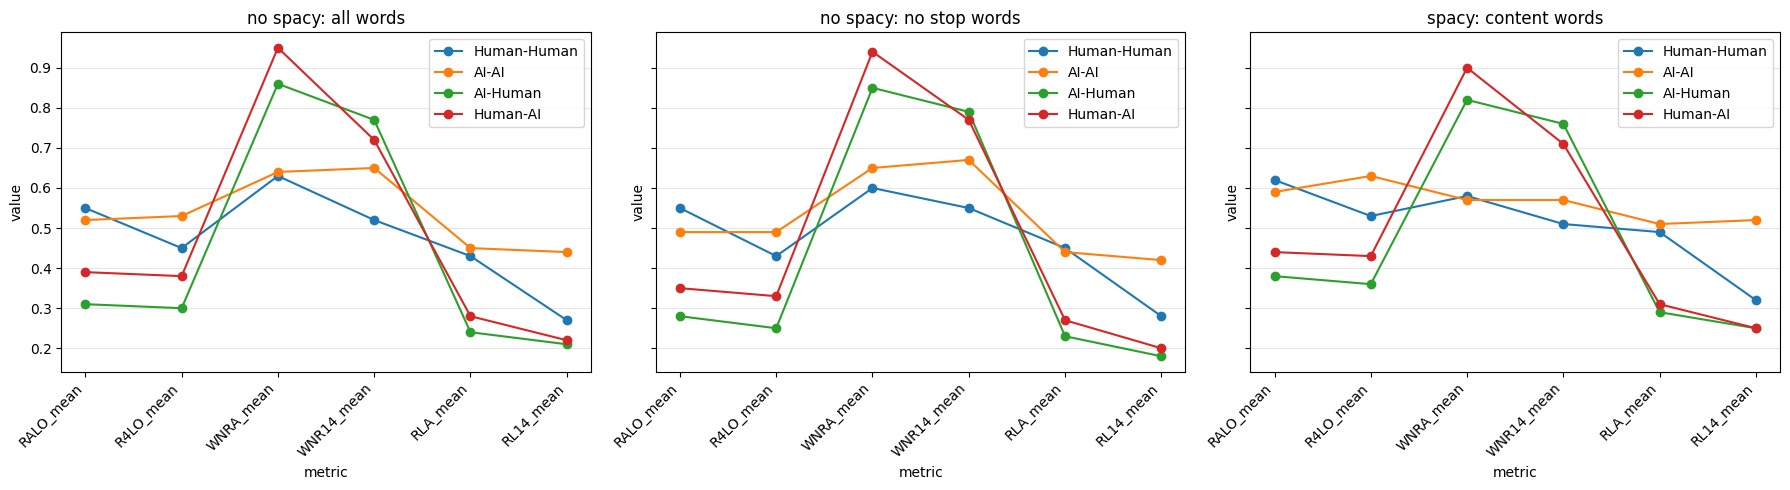

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# Your table (from your screenshot code)
cols = ["Human-Human", "AI-AI", "AI-Human", "Human-AI"]
tbl = results_df.pivot(index="condition", columns="method", values=["RALO_mean","R4LO_mean","WNRA_mean",
                                                              "WNR14_mean","RLA_mean","RL14_mean"]).T[cols].round(2)

metrics = ["RALO_mean", "R4LO_mean", "WNRA_mean", "WNR14_mean", "RLA_mean", "RL14_mean"]
methods = ["no spacy: all words", "no spacy: no stop words", "spacy: content words"]
conditions = cols

fig, axes = plt.subplots(1, len(methods), figsize=(18, 5), sharey=True)
x = np.arange(len(metrics))

for ax, method in zip(axes, methods):
    # tbl has MultiIndex rows: (metric, method)
    sub = tbl.xs(method, level=1)          # rows: metrics, cols: conditions
    sub = sub.loc[metrics, conditions]     # consistent order

    for cond in conditions:
        ax.plot(x, sub[cond].values, marker="o", label=cond)

    ax.set_title(method)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45, ha="right")
    ax.set_xlabel("metric")
    ax.grid(True, axis="y", alpha=0.3)

    ax.set_ylabel("value")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()


In [28]:
df_items_avg, df_summary_avg = compute_red_metrics(extracted_descriptions_piv, group_cols=["condition"])
df_summary_avg.round(2)

,condition,RALR_mean,R2LR_mean,R3LR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean,WNRA_mean,WNR14_mean,RLA_mean,RL14_mean,COSA_mean,COS14_mean,JACCA_mean,JACC14_mean
0,AI-AI,-0.02,-0.03,0.01,-0.04,0.50,0.59,0.63,0.57,0.57,0.51,0.52,0.82,0.87,0.51,0.51
1,AI-Human,0.09,0.07,0.13,0.06,0.55,0.38,0.36,0.82,0.76,0.29,0.25,0.66,0.65,0.26,0.22
2,Human-AI,-0.00,-0.06,-0.04,0.09,0.54,0.44,0.43,0.90,0.71,0.31,0.25,0.63,0.62,0.28,0.22
3,Human-Human,0.10,-0.02,0.10,0.23,0.52,0.62,0.53,0.58,0.51,0.49,0.32,0.74,0.62,0.43,0.27


In [14]:
compute_red_metrics(extracted_descriptions_piv, group_cols=["condition"], use_spacy=False)[1].round(2)

,condition,RALR_mean,R2LR_mean,R3LR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean,WNRA_mean,WNR14_mean,RLA_mean,RL14_mean,COSA_mean,COS14_mean,JACCA_mean,JACC14_mean
0,AI-AI,-0.02,-0.03,0.00,-0.05,0.47,0.49,0.49,0.65,0.67,0.44,0.42,0.84,0.86,0.37,0.35
1,AI-Human,0.10,0.09,0.13,0.08,0.54,0.28,0.25,0.85,0.79,0.23,0.18,0.71,0.68,0.17,0.13
2,Human-AI,-0.00,-0.03,-0.05,0.08,0.52,0.35,0.33,0.94,0.77,0.27,0.20,0.64,0.63,0.22,0.16
3,Human-Human,0.10,0.00,0.09,0.23,0.50,0.55,0.43,0.60,0.55,0.45,0.28,0.75,0.63,0.38,0.22


In [105]:
from src.data.utils import pretty_print

pretty_print(df_items_avg.sample(4))

,,round_ix,1,2,3,4,len_RED1,len_RED2,len_RED3,len_RED4,RALR,R2LR,R3LR,R4LR,LRMM,RALO,R4LO
pair_id,condition,filename,,,,,,,,,,,,,,,
63d3ccaecce99faa457fb049,Human-AI,001.png,"one shown upright, you can see a zig zag pattern along the top, It looks to have a 1"" approx rim, it's not really green, and not rectangular either, the deep oval one with the 1"" band and zig zag pattern","the one with the zig zags, the deep oval basket with a single arched handle and a chevron/zig‑zag band wrapping around near the top (about a 1-inch band)",zig zags,zig zags,41,28,2,2,0.739837,0.317073,0.951220,0.951220,0.666667,0.838710,0.50000
66e5e0262fb2c24edceb8e26,AI-Human,015.png,"a rectangular picnic-style basket, hinged lid that’s open/up on the right side, a tall vertical woven handle/strap rising near the center, More boxy than the others, flat top/lid","a rectangular, boxy picnic basket with a hinged lid that’s OPEN—one flap is sticking up on the RIGHT side, It also has a tall vertical woven strap/handle rising near the middle (so it looks like it’s split into two compartments)","a deep round bucket basket with a single thick arched handle that’s very dark brown/black, The body is warm brown with tight small weave, a smooth horizontal band around the rim, the deep round bucket basket with ONE big arch handle that’s almost black/dark brown, The body is warm brown with tight weave, there’s a smooth/plain band right around the rim","small rectangular picnic basket, hinged lid that’s OPEN—one flap is sticking up on the RIGHT side, tall vertical woven strap/handle in the middle, making it look like divided compartments",28,40,61,29,-0.547619,-0.428571,-1.178571,-0.035714,0.333333,0.355637,0.59375
knco59ak_d42tx12m_or8l74is,Human-Human,001.png,"has a round handle, the base is circular, the same color as the base, medium brown","a small medium brown basket, circular, one color","a smooth rim and a circular base, The base gets slightly smaller towards the bottom, its small and has a perfectly round handle, its symmetrical, the weaving is small, its kind of shiny","lighter brown, circular, and has light reflecting off the rim",16,8,33,10,-0.062500,0.500000,-1.062500,0.375000,0.666667,0.405303,0.40000
570521cfde5095001018a0c8,Human-AI,033.png,Mouse face,mouse with whiskers,mouse,mouse,2,3,1,1,0.166667,-0.500000,0.500000,0.500000,0.333333,0.777778,1.00000


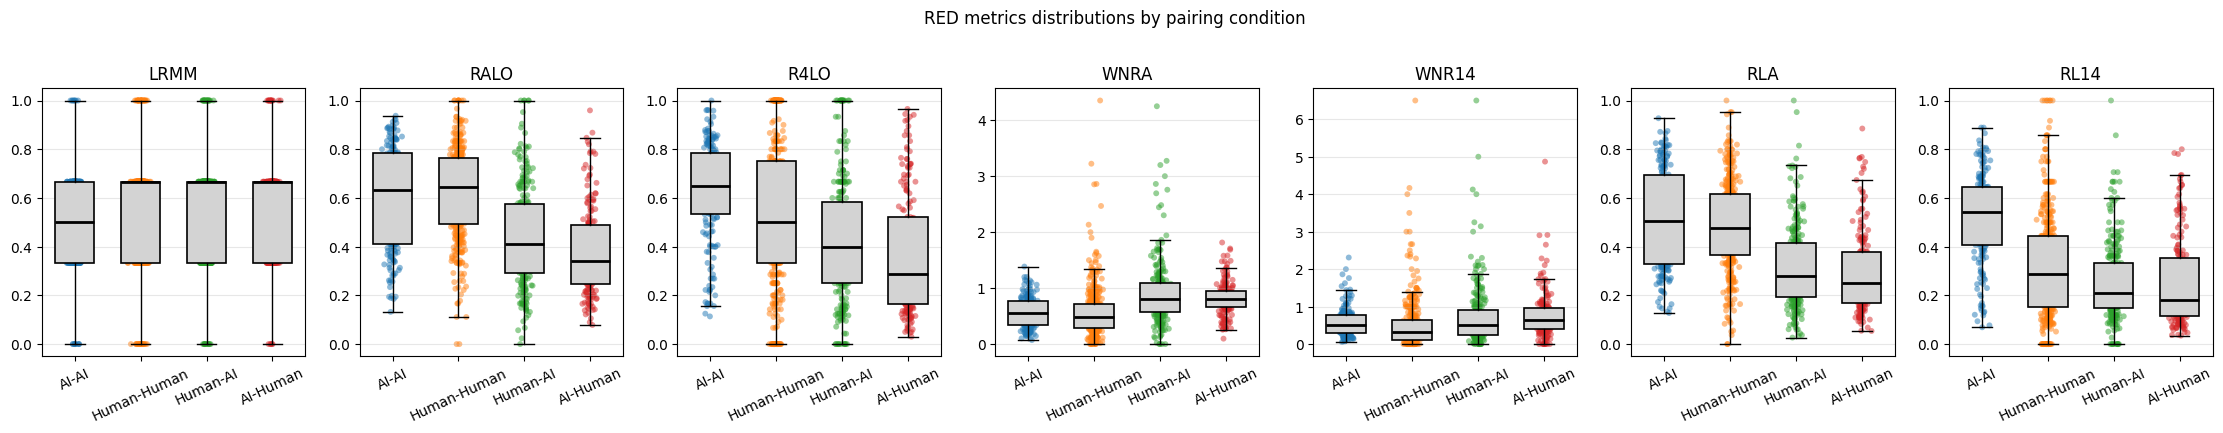

In [29]:
from src.evals.visualizers import plot_boxplots_by_condition

# cols = ['RALR', 'R2LR', 'R3LR', 'R4LR', 'LRMM', 'RALO', 'R4LO']
cols = ['LRMM', 'RALO', 'R4LO', 'WNRA', 'WNR14', 'RLA', 'RL14']


fig, axes = plot_boxplots_by_condition(
    df_items_avg.reset_index(),
    cols,
    condition_col="condition",
    title="RED metrics distributions by pairing condition",
    save_fp=None,  # e.g. "boxplots.png"
)
fig.show()

## Lexical Adaptation

In [7]:
from src.evals.red import computer_lexical_adaptation


la_df = computer_lexical_adaptation(extracted_descriptions_piv.reset_index(), against_t1_only=True)
la_df

,pair_id,condition,round_ix,Len Reduction Rate,Lexical Overlap,Word Novelty Rate,Rouge-L,SBERT Cosim,Jaccard
0,12mwnjm1,AI-AI,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,12mwnjm1,AI-AI,2,1.212121,0.700000,0.575758,0.657534,0.959009,0.647059
2,12mwnjm1,AI-AI,3,1.272727,0.714286,0.484848,0.746667,0.948393,0.705882
3,12mwnjm1,AI-AI,4,1.454545,0.520833,0.818182,0.543210,0.901311,0.488372
4,12mwnjm1,AI-AI,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...
4123,y5q3cuyo,AI-AI,4,1.360000,0.647059,0.480000,0.745763,0.942817,0.709677
4124,y5q3cuyo,AI-AI,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4125,y5q3cuyo,AI-AI,2,0.918919,0.588235,0.432432,0.563380,0.897269,0.428571
4126,y5q3cuyo,AI-AI,3,0.918919,0.705882,0.351351,0.647887,0.871131,0.526316


In [42]:
la_df[la_df.columns.to_list()[3:]].corr()

,Len Reduction Rate,Lexical Overlap,Word Novelty Rate,Rouge-L,SBERT Cosim,Jaccard
Len Reduction Rate,1.000000,-0.229570,0.942601,0.025676,0.051724,0.038796
Lexical Overlap,-0.229570,1.000000,-0.230661,0.864127,0.780827,0.868884
Word Novelty Rate,0.942601,-0.230661,1.000000,0.024025,0.012102,0.051249
Rouge-L,0.025676,0.864127,0.024025,1.000000,0.848493,0.981213
SBERT Cosim,0.051724,0.780827,0.012102,0.848493,1.000000,0.851275
Jaccard,0.038796,0.868884,0.051249,0.981213,0.851275,1.000000


In [43]:
la_df[la_df.columns.to_list()[3:]].corr("spearman")

,Len Reduction Rate,Lexical Overlap,Word Novelty Rate,Rouge-L,SBERT Cosim,Jaccard
Len Reduction Rate,1.000000,-0.034750,0.831123,0.312108,0.325248,0.331716
Lexical Overlap,-0.034750,1.000000,-0.072637,0.873588,0.818019,0.882656
Word Novelty Rate,0.831123,-0.072637,1.000000,0.200639,0.260051,0.237514
Rouge-L,0.312108,0.873588,0.200639,1.000000,0.905072,0.974442
SBERT Cosim,0.325248,0.818019,0.260051,0.905072,1.000000,0.928862
Jaccard,0.331716,0.882656,0.237514,0.974442,0.928862,1.000000


In [11]:
len(la_df.dropna())

4083

In [81]:
la_df[la_df.columns.to_list()[3:]].describe()

,Len Reduction Rate,Lexical Overlap,Word Novelty Rate,Rouge-L,SBERT Cosim,Jaccard
count,4108.000000,4103.000000,4108.000000,4083.000000,4128.000000,4128.000000
mean,1.045696,0.641394,0.775071,0.560023,0.786463,0.531082
std,0.732193,0.335557,0.747856,0.348310,0.220003,0.361296
min,0.000000,0.000000,0.000000,0.000000,-0.049150,0.000000
25%,0.777778,0.333333,0.312500,0.225176,0.641567,0.181818
50%,1.000000,0.700000,0.769231,0.531250,0.842042,0.500000
75%,1.050658,1.000000,1.000000,1.000000,1.000000,1.000000
max,13.000000,1.000000,12.250000,1.000000,1.000000,1.000000


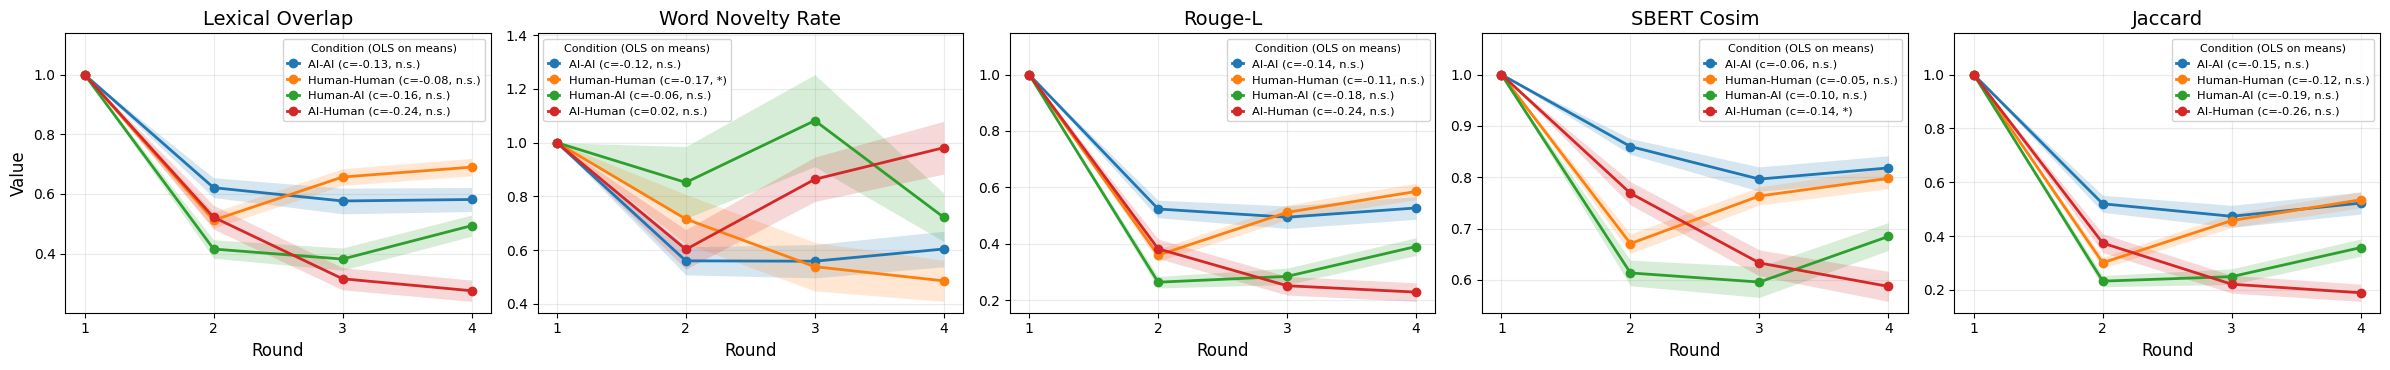

In [13]:
from src.evals.visualizers import plot_metrics_grid

fig, axes = plot_metrics_grid(la_df, la_df.columns.to_list()[4:], nrows=1, 
                              show_points=False, legend_loc="best")
fig.show()

In [14]:
# from src.evals.visualizers import plot_ols_metrics_grid

# fig, axes = plot_ols_metrics_grid(la_df, la_df.columns.to_list()[4:], nrows=1, show_points=False)
# fig.show()

### Accuracy-Efficiency-Entrainment

In [33]:
import pandas as pd

efficiency_df_annotated = pd.read_json("consolidated_results/efficiency_results_with_red_annotations.json")
efficiency_df_annotated.columns, efficiency_df_annotated.shape

(Index(['pair_id', 'condition', 'round_ix', 'accuracy', 'transcript', '# words',
        '# turns', '# utterances', 'words_per_turn', 'words_per_utterance',
        'utterances_per_turn', 'round_duration_seconds',
        'avg_turn_duration_seconds', 'avg_utterance_duration_seconds',
        'round_duration', 'avg_turn_duration', 'avg_utterance_duration',
        'llm_extracted_object_descriptions_GPT_5', 'extracted_descriptions',
        'red_tokens', 'avg_clip_score', 'avg_contrastive_clip_score', 'Jaccard',
        'Len Reduction Rate', 'Lexical Overlap (Lexical Entrainment)',
        'Rouge-L', 'SBERT Cosim', 'Word Novelty Rate'],
       dtype='object'),
 (344, 28))

In [34]:
efficiency_df_annotated.groupby("condition")["accuracy"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
AI-AI,64.0,85.81,10.67,66.67,75.00,91.67,91.67,100.00
AI-Human,64.0,54.56,27.38,8.33,31.25,50.00,83.33,100.00
Human-AI,88.0,59.28,17.25,16.67,50.00,58.33,75.00,91.67
Human-Human,128.0,87.30,19.11,25.00,83.33,100.00,100.00,100.00


In [35]:
cols_renamer = {
    "accuracy": "Accuracy (Communicative Success)",
    "# words": "Number of Words (Communicative Effort)",
    "# turns": "Number of Turns (Communicative Effort)",
    "red_tokens": "Number of RE Words (Lexical Entrainment)", 
    # "avg_clip_score": "CLIP Score",
    # "avg_contrastive_clip_score": "Contrastive CLIP Score",
    "Lexical Overlap (Lexical Entrainment)": "Proportion of Lexical Overlap (Lexical Entrainment)"
}
efficiency_df_annotated.rename(columns=cols_renamer, inplace=True)
efficiency_df_annotated.columns

Index(['pair_id', 'condition', 'round_ix', 'Accuracy (Communicative Success)',
       'transcript', 'Number of Words (Communicative Effort)',
       'Number of Turns (Communicative Effort)', '# utterances',
       'words_per_turn', 'words_per_utterance', 'utterances_per_turn',
       'round_duration_seconds', 'avg_turn_duration_seconds',
       'avg_utterance_duration_seconds', 'round_duration', 'avg_turn_duration',
       'avg_utterance_duration', 'llm_extracted_object_descriptions_GPT_5',
       'extracted_descriptions', 'Number of RE Words (Lexical Entrainment)',
       'avg_clip_score', 'avg_contrastive_clip_score', 'Jaccard',
       'Len Reduction Rate',
       'Proportion of Lexical Overlap (Lexical Entrainment)', 'Rouge-L',
       'SBERT Cosim', 'Word Novelty Rate'],
      dtype='object')

In [36]:
# from src.evals.visualizers import plot_ols_metrics_grid

# metrics_cols = ["CLIP Score", "Contrastive CLIP Score"]
# fig, axes = plot_ols_metrics_grid(efficiency_df_annotated, metrics_cols, nrows=1, 
#                                   show_points=False, figsize=(7, 5.75),
#                                   )
# fig.show()

In [37]:
metrics_cols = list(cols_renamer.values())
metrics_cols

['Accuracy (Communicative Success)',
 'Number of Words (Communicative Effort)',
 'Number of Turns (Communicative Effort)',
 'Number of RE Words (Lexical Entrainment)',
 'Proportion of Lexical Overlap (Lexical Entrainment)']

In [38]:
# ["mean", "std"]
efficiency_df_annotated.groupby(["condition", "round_ix"])[metrics_cols].describe().round(2).T

condition                                                   AI-AI           \
round_ix                                                        1        2   
Accuracy (Communicative Success)                   count    16.00    16.00   
                                                   mean     92.19    90.10   
                                                   std       6.43     9.73   
                                                   min      75.00    66.67   
                                                   25%      91.67    83.33   
                                                   50%      91.67    91.67   
                                                   75%      93.75   100.00   
                                                   max     100.00   100.00   
Number of Words (Communicative Effort)             count    16.00    16.00   
                                                   mean   1354.94  1403.00   
                                                   std     136.36   141.77   
                                                   min    1156.00  1147.00   
                                                   25%    1272.50  1338.25   
                                                   50%    1333.50  1404.00   
                                                   75%    1405.50  1468.50   
                                                   max    1654.00  1672.00   
Number of Turns (Communicative Effort)             count    16.00    16.00   
                                                   mean     29.50    30.25   
                                                   std       3.76     3.99   
                                                   min      24.00    24.00   
                                                   25%      27.50    28.00   
                                                   50%      28.00    29.00   
                                                   75%      32.00    34.00   
                                                   max      38.00    38.00   
Number of RE Words (Lexical Entrainment)           count    16.00    16.00   
                                                   mean    446.12   437.44   
                                                   std      33.50    57.82   
                                                   min     392.00   346.00   
                                                   25%     429.50   375.00   
                                                   50%     445.50   449.50   
                                                   75%     470.75   479.50   
                                                   max     498.00   519.00   
Proportion of Lexical Overlap (Lexical Entrainm... count    16.00    16.00   
                                                   mean      1.00     0.62   
                                                   std       0.00     0.06   
                                                   min       1.00     0.51   
                                                   25%       1.00     0.58   
                                                   50%       1.00     0.63   
                                                   75%       1.00     0.67   
                                                   max       1.00     0.71   

condition                                                                   \
round_ix                                                        3        4   
Accuracy (Communicative Success)                   count    16.00    16.00   
                                                   mean     84.38    76.56   
                                                   std      10.03     9.24   
                                                   min      66.67    66.67   
                                                   25%      81.25    66.67   
                                                   50%      83.33    75.00   
                                                   75%      91.67    83.33   
                     

In [39]:
# repalce 1 with nan

efficiency_df_annotated[metrics_cols[-1]] = efficiency_df_annotated[metrics_cols[-1]].replace(1, pd.NA)

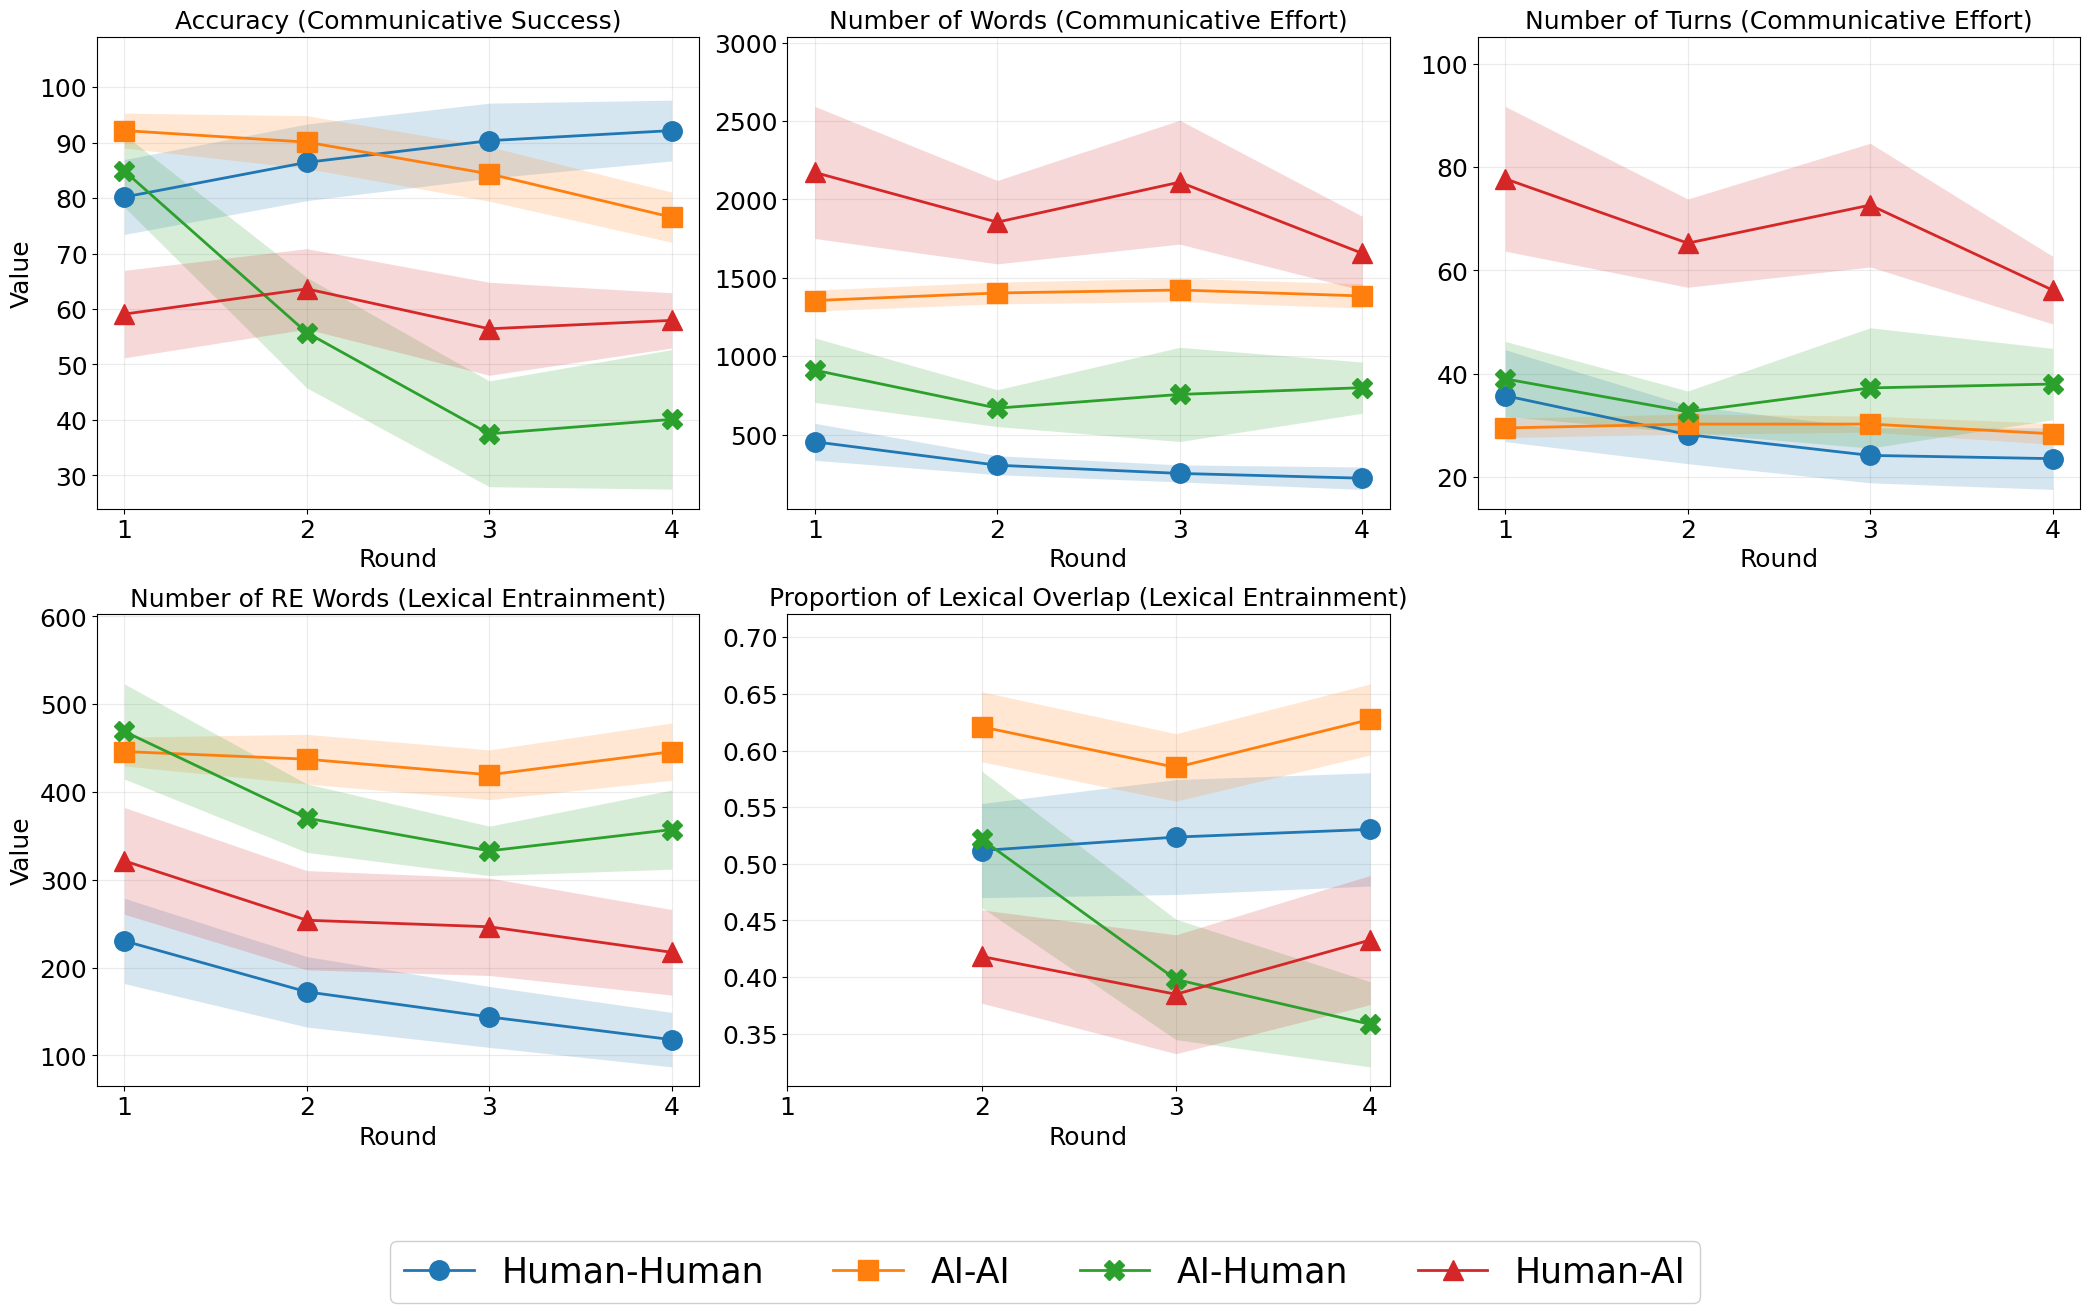

In [40]:
from src.evals.visualizers import plot_metrics_grid


# "CLIP Score", "Contrastive CLIP Score"
metrics_cols = list(cols_renamer.values())
metrics_ymax_dict = {
    "Accuracy (Communicative Success)": 100,
    "Number of Words (Communication Effort)": None,
    "Number of Turns (Communication Effort)": None,
    "Number of RE Words (Lexical Entrainment)": None,
    # "Proportion of Lexical Overlap (Lexical Entrainment)": 1,
}

# default_markers = ["o", "s", "P", "X", "*", "X", "D", "v"]
# marker_map = dict(zip(metrics_cols, default_markers))

fig, axes = plot_metrics_grid(efficiency_df_annotated, metrics_cols, nrows=2, 
                              show_significance=False,
                                show_points=False, figsize=(7, 6.5), legend_loc="best",
                                metrics_ymax_dict=metrics_ymax_dict,
                                global_legend=True,
                                sharex=False, 
                                point_size=10,
                                markersize=14,
                                # marker_map=marker_map,
                                global_legend_loc="lower center",
                                global_legend_bbox_to_anchor=(0.5, -0.02),
                                global_legend_ncol=4,
                                global_legend_top_pad=0.14,
                                global_legend_fontsize=25,
                                global_legend_title_fontsize=35,
                                save_fp="figures/ols_accuracy_efficiency_entrainment.png")
fig.show()

In [23]:
piv_res = efficiency_df_annotated.pivot_table(index="condition", columns="round_ix", values=metrics_cols, aggfunc=['median', 'mean', "std"]).T.round(1)
print(piv_res.to_latex(float_format="%.1f"))

\begin{tabular}{lllrrrr}
\toprule
 &  & condition & AI-AI & AI-Human & Human-AI & Human-Human \\
 &  & round_ix &  &  &  &  \\
\midrule
\multirow[t]{12}{*}{median} & \multirow[t]{4}{*}{Accuracy} & 1 & 91.7 & 87.5 & 58.3 & 83.3 \\
 &  & 2 & 91.7 & 54.2 & 58.3 & 91.7 \\
 &  & 3 & 83.3 & 33.3 & 66.7 & 100.0 \\
 &  & 4 & 75.0 & 33.3 & 58.3 & 100.0 \\
\cline{2-7}
 & \multirow[t]{4}{*}{Number of RED Tokens} & 1 & 445.5 & 446.0 & 304.5 & 186.5 \\
 &  & 2 & 449.5 & 355.5 & 261.0 & 131.5 \\
 &  & 3 & 425.5 & 315.5 & 236.0 & 112.0 \\
 &  & 4 & 437.5 & 346.0 & 186.0 & 99.0 \\
\cline{2-7}
 & \multirow[t]{4}{*}{Number of Tokens} & 1 & 1333.5 & 765.5 & 1980.5 & 374.5 \\
 &  & 2 & 1404.0 & 643.5 & 1948.5 & 293.5 \\
 &  & 3 & 1385.5 & 564.0 & 2143.5 & 213.5 \\
 &  & 4 & 1313.5 & 680.0 & 1559.5 & 161.0 \\
\cline{1-7} \cline{2-7}
\multirow[t]{12}{*}{mean} & \multirow[t]{4}{*}{Accuracy} & 1 & 92.2 & 84.9 & 59.1 & 80.2 \\
 &  & 2 & 90.1 & 55.7 & 63.6 & 86.5 \\
 &  & 3 & 84.4 & 37.5 & 56.4 & 90.4 \\
 &  & 

In [24]:
piv_res

condition                              AI-AI  AI-Human  Human-AI  Human-Human
                            round_ix                                         
median Accuracy             1           91.7      87.5      58.3         83.3
                            2           91.7      54.2      58.3         91.7
                            3           83.3      33.3      66.7        100.0
                            4           75.0      33.3      58.3        100.0
       Number of RED Tokens 1          445.5     446.0     304.5        186.5
                            2          449.5     355.5     261.0        131.5
                            3          425.5     315.5     236.0        112.0
                            4          437.5     346.0     186.0         99.0
       Number of Tokens     1         1333.5     765.5    1980.5        374.5
                            2         1404.0     643.5    1948.5        293.5
                            3         1385.5     564.0    2143.5        213.5
                            4         1313.5     680.0    1559.5        161.0
mean   Accuracy             1           92.2      84.9      59.1         80.2
                            2           90.1      55.7      63.6         86.5
                            3           84.4      37.5      56.4         90.4
                            4           76.6      40.1      58.0         92.2
       Number of RED Tokens 1          446.1     469.0     321.6        230.4
                            2          437.4     370.2     254.0        172.4
                            3          419.7     333.0     246.5        143.9
                            4          446.0     357.2     217.5        118.0
       Number of Tokens     1         1354.9     910.8    2171.6        454.2
                            2         1403.0     668.7    1854.7        304.9
                            3         1422.1     756.2    2109.7        252.4
                            4         1384.1     799.3    1656.1        221.9
std    Accuracy             1            6.4      13.3      18.9         19.5
                            2            9.7      20.3      17.4         19.9
                            3           10.0      19.5      20.1         19.5
                            4            9.2      25.7      11.9         15.8
       Number of RED Tokens 1           33.5     110.6     145.6        140.2
                            2           57.8      79.6     135.2        115.8
                            3           57.8      57.5     132.9        100.2
                            4           66.6      92.0     116.6         89.7
       Number of Tokens     1          136.4     420.0    1007.9        340.5
                            2          141.8     239.8     636.3        175.0
                            3          151.4     613.3     945.1        156.9
                            4          158.3     333.8     565.7        206.6

In [67]:
from __future__ import annotations

from typing import Sequence, Tuple, Optional
import re

import numpy as np
import pandas as pd
import statsmodels.api as sm


def ols_results_table_by_condition(
    df: pd.DataFrame,
    metrics: list[str],
    *,
    condition_col: str = "condition",
    x_col: str = "round_ix",
    precision: int = 3,
    # significance display tuning
    star_levels: Sequence[Tuple[float, str]] = ((0.001, "***"), (0.01, "**"), (0.05, "*")),
    ns_label: str = "n.s.",
    show_ns: bool = False,
    # color tuning (hex or any CSS-like color accepted by pandas Styler; LaTeX uses hex -> RGB)
    pos_color: str = "#1a7f37",   # green
    neg_color: str = "#d1242f",   # red
    zero_color: str = "#6e7781",  # gray
    na_color: str = "#6e7781",
    color_mode: str = "text",     # "text" or "background" (for pandas Styler)
    # stats tuning
    robust_se: bool = False,      # if True, uses HC3 robust SE for p-values
    # ordering
    condition_order: Optional[Sequence[str]] = None,
    # NEW: transpose output
    transpose: bool = False,      # if True: rows=metrics, cols=conditions
    # LaTeX output tuning
    latex_color_mode: str = "text",     # "text", "background", or "none"
    latex_background_alpha: int = 15,   # only used when latex_color_mode="background" (0-100)
    latex_caption: Optional[str] = None,
    latex_label: Optional[str] = None,
    latex_float: bool = True,
    latex_escape: bool = True,
) -> tuple[pd.DataFrame, "pd.io.formats.style.Styler", str]:
    """
    Build a table of OLS slope (c) + significance stars for each (condition, metric),
    fitting OLS on ALL RAW POINTS within each condition (not per-round means).

    Default orientation:
      - rows = conditions, cols = metrics

    If transpose=True:
      - rows = metrics, cols = conditions

    Returns:
      - df_out: DataFrame of formatted strings like '0.123***'
      - styler: pandas Styler with conditional coloring (for notebooks)
      - latex: LaTeX table string suitable for Overleaf
    """
    if condition_col not in df.columns or x_col not in df.columns:
        raise ValueError(f"df must contain '{condition_col}' and '{x_col}' columns")
    missing = [m for m in metrics if m not in df.columns]
    if missing:
        raise ValueError(f"These metrics are not in df columns: {missing}")

    def _hex_to_rgb(hex_color: str) -> tuple[int, int, int]:
        s = hex_color.strip()
        if s.startswith("#"):
            s = s[1:]
        if len(s) == 3:
            s = "".join([ch * 2 for ch in s])
        if not re.fullmatch(r"[0-9a-fA-F]{6}", s):
            s = "000000"
        return int(s[0:2], 16), int(s[2:4], 16), int(s[4:6], 16)

    def _latex_escape(s: str) -> str:
        if not latex_escape:
            return s
        repl = {
            "\\": r"\textbackslash{}",
            "&": r"\&",
            "%": r"\%",
            "$": r"\$",
            "#": r"\#",
            "_": r"\_",
            "{": r"\{",
            "}": r"\}",
            "~": r"\textasciitilde{}",
            "^": r"\textasciicircum{}",
        }
        return "".join(repl.get(ch, ch) for ch in s)

    def stars_for_p(p: float) -> str:
        if not np.isfinite(p):
            return ""
        for alpha, sym in star_levels:
            if p < alpha:
                return sym
        return ns_label if show_ns else ""

    # prepare data
    data = df.copy()
    data = data.dropna(subset=[condition_col, x_col])
    data[x_col] = pd.to_numeric(data[x_col], errors="coerce")
    data = data.dropna(subset=[x_col])

    # condition ordering
    if condition_order is None:
        conditions = list(pd.unique(data[condition_col]))
    else:
        present = set(pd.unique(data[condition_col]))
        conditions = [c for c in condition_order if c in present]

    # compute: conditions x metrics
    out_str_cm = pd.DataFrame(index=conditions, columns=metrics, dtype=object)
    out_slope_cm = pd.DataFrame(index=conditions, columns=metrics, dtype=float)

    for cond in conditions:
        dcond = data[data[condition_col] == cond]
        for metric in metrics:
            d = dcond.dropna(subset=[metric]).copy()
            if d.empty or d[x_col].nunique() < 2:
                out_str_cm.loc[cond, metric] = ""
                out_slope_cm.loc[cond, metric] = np.nan
                continue

            d[metric] = pd.to_numeric(d[metric], errors="coerce")
            d = d.dropna(subset=[metric])
            if d.empty or d[x_col].nunique() < 2:
                out_str_cm.loc[cond, metric] = ""
                out_slope_cm.loc[cond, metric] = np.nan
                continue

            X = sm.add_constant(d[x_col].astype(float))
            y = d[metric].astype(float)
            fit = sm.OLS(y, X).fit(cov_type="HC3") if robust_se else sm.OLS(y, X).fit()

            slope = float(fit.params.get(x_col, np.nan))
            pval = float(fit.pvalues.get(x_col, np.nan))

            out_slope_cm.loc[cond, metric] = slope
            out_str_cm.loc[cond, metric] = (
                f"{slope:.{precision}f}{stars_for_p(pval)}" if np.isfinite(slope) else ""
            )

    # orient
    if transpose:
        out_str = out_str_cm.T
        out_slope = out_slope_cm.T
        out_str.index.name = "metric"
        out_str.columns.name = condition_col
    else:
        out_str = out_str_cm
        out_slope = out_slope_cm
        out_str.index.name = condition_col
        out_str.columns.name = "metric"

    # ---------- pandas Styler coloring ----------
    def _style_cell(val_str: str, slope_val: float) -> str:
        if val_str is None or val_str == "" or (not np.isfinite(slope_val)):
            return f"color: {na_color};" if color_mode == "text" else ""
        if slope_val > 0:
            return f"color: {pos_color};" if color_mode == "text" else f"background-color: {pos_color};"
        if slope_val < 0:
            return f"color: {neg_color};" if color_mode == "text" else f"background-color: {neg_color};"
        return f"color: {zero_color};" if color_mode == "text" else f"background-color: {zero_color};"

    style_df = pd.DataFrame(index=out_str.index, columns=out_str.columns, dtype=object)
    for r in out_str.index:
        for c in out_str.columns:
            style_df.loc[r, c] = _style_cell(out_str.loc[r, c], out_slope.loc[r, c])

    styler = (
        out_str.style
        .apply(lambda _: style_df, axis=None)
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
    )

    # ---------- LaTeX table ----------
    pos_rgb = _hex_to_rgb(pos_color)
    neg_rgb = _hex_to_rgb(neg_color)
    zero_rgb = _hex_to_rgb(zero_color)
    na_rgb = _hex_to_rgb(na_color)

    def _latex_color_wrap(cell_text: str, slope_val: float) -> str:
        ct = _latex_escape(cell_text or "")
        if cell_text is None or cell_text == "" or (not np.isfinite(slope_val)):
            if latex_color_mode == "text":
                return r"\textcolor{naColor}{" + ct + "}"
            if latex_color_mode == "background":
                return r"\cellcolor{naColor!" + str(latex_background_alpha) + "}" + ct
            return ct

        if slope_val > 0:
            if latex_color_mode == "text":
                return r"\textcolor{posColor}{" + ct + "}"
            if latex_color_mode == "background":
                return r"\cellcolor{posColor!" + str(latex_background_alpha) + "}" + ct
            return ct
        if slope_val < 0:
            if latex_color_mode == "text":
                return r"\textcolor{negColor}{" + ct + "}"
            if latex_color_mode == "background":
                return r"\cellcolor{negColor!" + str(latex_background_alpha) + "}" + ct
            return ct

        if latex_color_mode == "text":
            return r"\textcolor{zeroColor}{" + ct + "}"
        if latex_color_mode == "background":
            return r"\cellcolor{zeroColor!" + str(latex_background_alpha) + "}" + ct
        return ct

    # headers based on orientation
    row_header = out_str.index.name or "row"
    col_headers = [str(c) for c in out_str.columns]

    lines: list[str] = []
    if latex_float:
        lines.append(r"\begin{table}[t]")
        lines.append(r"\centering")

    # define colors (requires xcolor)
    lines.append(r"\definecolor{posColor}{RGB}{" + f"{pos_rgb[0]},{pos_rgb[1]},{pos_rgb[2]}" + r"}")
    lines.append(r"\definecolor{negColor}{RGB}{" + f"{neg_rgb[0]},{neg_rgb[1]},{neg_rgb[2]}" + r"}")
    lines.append(r"\definecolor{zeroColor}{RGB}{" + f"{zero_rgb[0]},{zero_rgb[1]},{zero_rgb[2]}" + r"}")
    lines.append(r"\definecolor{naColor}{RGB}{" + f"{na_rgb[0]},{na_rgb[1]},{na_rgb[2]}" + r"}")

    col_spec = "l" + "c" * len(col_headers)
    lines.append(r"\begin{tabular}{" + col_spec + r"}")
    lines.append(r"\toprule")
    lines.append(" & ".join([_latex_escape(str(row_header))] + [_latex_escape(h) for h in col_headers]) + r" \\")
    lines.append(r"\midrule")

    for r in out_str.index:
        row_cells = [_latex_escape(str(r))]
        for c in out_str.columns:
            row_cells.append(_latex_color_wrap(out_str.loc[r, c], out_slope.loc[r, c]))
        lines.append(" & ".join(row_cells) + r" \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    if latex_caption:
        lines.append(r"\caption{" + _latex_escape(latex_caption) + r"}")
    if latex_label:
        lines.append(r"\label{" + _latex_escape(latex_label) + r"}")

    if latex_float:
        lines.append(r"\end{table}")

    latex = "\n".join(lines)

    return out_str, styler, latex


In [68]:
efficiency_df_annotated

,pair_id,condition,round_ix,Accuracy (Communicative Success),transcript,Number of Words (Communication Effort),Number of Turns (Communication Effort),# utterances,words_per_turn,words_per_utterance,...,extracted_descriptions,Number of RE Words (Lexical Entrainment),avg_clip_score,avg_contrastive_clip_score,Jaccard,Len Reduction Rate,Proportion of Lexical Overlap (Lexical Entrainment),Rouge-L,SBERT Cosim,Word Novelty Rate
0,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,1,83.333333,[18:27:25] director: Hi there. The first baske...,374,32,33,11.687500,11.333333,...,"{'object_#1': 'rabbit facing to the right', 'o...",189,24.211711,8.881784e-16,1.000000,1.000000,<NA>,1.000000,1.000000,1.000000
1,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,2,91.666667,[18:47:04] director: hi there \n\n[18:47:11] m...,352,31,34,11.354839,10.352941,...,"{'object_#1': 'a rectangle basket, the right s...",238,25.974450,-8.881784e-16,0.439956,1.275217,0.553903,0.505885,0.796534,0.768371
2,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,3,91.666667,[19:05:34] director: hi there \n\n[19:05:41] m...,268,26,26,10.307692,10.307692,...,"{'object_#1': '2 tone basket, dark brown body ...",186,26.148132,-2.590520e-16,0.405356,1.155591,0.550211,0.468648,0.808890,0.727767
3,3kk7u0fy_08dnx2dx_ljtwijvs,Human-Human,4,83.333333,[19:16:36] director: hi there! \n\n[19:16:42] ...,299,27,27,11.074074,11.074074,...,{'object_#1': 'shallow light colored basket wi...,241,26.786430,9.251859e-16,0.395668,1.404203,0.494547,0.437084,0.784216,0.951247
4,3kk7u0fy_2ifxj59u_qhyb02an,Human-Human,1,91.666667,[18:16:40] director: 1 the rabbit facing your ...,299,19,38,15.736842,7.868421,...,"{'object_#1': 'the rabbit facing your right', ...",184,18.289993,5.921189e-16,1.000000,1.000000,<NA>,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,570521cfde5095001018a0c8,Human-AI,4,58.333333,[20:14:55] director: Round shallow basket with...,1090,44,44,24.772727,24.772727,...,{'object_#1': 'Round shallow basket with circu...,124,22.329786,5.921189e-16,0.130843,1.085475,0.305278,0.192741,0.571635,0.905538
340,63614ad9841a7d16ad04512a,Human-AI,1,83.333333,[21:12:09] director: First You have a rabbit w...,1255,42,42,29.880952,29.880952,...,"{'object_#1': 'a rabbit with the fur down, no ...",194,23.409581,0.000000e+00,1.000000,1.000000,<NA>,1.000000,1.000000,1.000000
341,63614ad9841a7d16ad04512a,Human-AI,2,75.000000,[21:31:30] director: for number 1we have a thi...,1328,42,43,31.619048,30.883721,...,{'object_#1': 'a thick basket with a handle go...,133,18.432509,-8.333333e-02,0.275585,0.822248,0.46304,0.358240,0.551599,0.582547
342,63614ad9841a7d16ad04512a,Human-AI,3,66.666667,[21:58:55] director: 1 has the tteal with ligh...,1088,38,38,28.631579,28.631579,...,{'object_#1': 'tteal with lighter bands on the...,133,19.878457,0.000000e+00,0.137949,0.841931,0.283649,0.196036,0.518341,0.725936


In [70]:
out_str, styler, latex= ols_results_table_by_condition(
    efficiency_df_annotated,
    metrics=metrics_cols,
    condition_col="condition",
    x_col="round_ix",
    precision=1,
    pos_color="#00aa00",
    neg_color="#cc0000",
    star_levels=((0.001, "***"), (0.01, "**"), (0.05, "*")),
    show_ns=False,
    robust_se=False,
    transpose=True,
)
styler  # in notebooks, this renders the colored table


condition,Human-Human,AI-AI,AI-Human,Human-AI
metric,,,,
Accuracy (Communicative Success),4.0**,-5.3***,-15.3***,-1.1
Number of Words (Communication Effort),-74.9***,10.6,-24.7,-129.1
Number of Turns (Communication Effort),-4.1**,-0.3,0.2,-5.7*
Number of RE Words (Lexical Entrainment),-36.6***,-1.8,-37.3***,-32.0*
Proportion of Lexical Overlap (Lexical Entrainment),0.0,0.0,-0.1***,0.0


In [71]:
print(latex)

\begin{table}[t]
\centering
\definecolor{posColor}{RGB}{0,170,0}
\definecolor{negColor}{RGB}{204,0,0}
\definecolor{zeroColor}{RGB}{110,119,129}
\definecolor{naColor}{RGB}{110,119,129}
\begin{tabular}{lcccc}
\toprule
metric & Human-Human & AI-AI & AI-Human & Human-AI \\
\midrule
Accuracy (Communicative Success) & \textcolor{posColor}{4.0**} & \textcolor{negColor}{-5.3***} & \textcolor{negColor}{-15.3***} & \textcolor{negColor}{-1.1} \\
Number of Words (Communication Effort) & \textcolor{negColor}{-74.9***} & \textcolor{posColor}{10.6} & \textcolor{negColor}{-24.7} & \textcolor{negColor}{-129.1} \\
Number of Turns (Communication Effort) & \textcolor{negColor}{-4.1**} & \textcolor{negColor}{-0.3} & \textcolor{posColor}{0.2} & \textcolor{negColor}{-5.7*} \\
Number of RE Words (Lexical Entrainment) & \textcolor{negColor}{-36.6***} & \textcolor{negColor}{-1.8} & \textcolor{negColor}{-37.3***} & \textcolor{negColor}{-32.0*} \\
Proportion of Lexical Overlap (Lexical Entrainment) & \textcolor{p